# Nonlinear first-order PDEs: implicit characteristics

We use inviscid Burgers with smooth initial data, $u_t+u u_x=0$, $u(x,0)=x^2$, to illustrate why an implicit characteristic relation is a first-class symbolic result rather than a failed explicit solve.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. DerivationAlong a characteristic,$$\dot x=u,\qquad \dot u=0.$$If the characteristic starts at $x(0)=\xi$, then $u=\xi^2$ and$$x=\xi+t\xi^2.$$Eliminating $\xi$ using $\xi=x-tu$ gives$$\boxed{u=(x-tu)^2}.$$This equation defines the classical solution implicitly until characteristics cross.

In [3]:
x, t = sp.symbols("x t", real=True)
u = sp.Function("u")
eq = sp.Eq(sp.diff(u(x,t),t) + u(x,t)*sp.diff(u(x,t),x), 0)
problem = pds.build_pde_problem(eq, u(x,t), (x,t), ics={"initial_profile": x**2})
recognition, plan = show_plan(problem)

Recognition: (PDERecognitionRecord(family='scalar_conservation_law', recognized=True, solver_hint='conservation_law', tags=('weak_solution', 'riemann_ready'), metadata={'canonical_family': 'transport_reaction'}), PDERecognitionRecord(family='quasilinear_scalar_ivp', recognized=True, solver_hint='quasilinear_implicit', tags=('characteristics',), metadata={}))Top plan steps:  quasilinear_implicit                       score=98  first_order_nonlinear_auto                 score=86  charpit                                    score=84  conservation_law                           score=82  complete_integral                          score=78  invariant_reduction_auto                   score=74

In [4]:
result = pds.pdesolve(eq, u(x,t), (x,t), ics={"initial_profile": x**2}, method="quasilinear_implicit")
print(type(result).__name__, result.method)
display(result.solution)
print("Verification:", result.verification)

PDESolutionRecord quasilinear_implicit_characteristics

Verification: {'verified': None, 'status': 'unverified', 'pde_verified': None, 'initial_verified': None, 'boundary_verified': None, 'pde_residual': None, 'initial_residuals': (), 'boundary_residuals': (), 'mode': 'method_specific', 'message': 'skipped expensive generic verification for implicit/weak first-order solution'}

## 2. Method-specific verificationGeneric substitution is not appropriate because the returned equation contains $u(x,t)$ on both sides. Instead we compare it with the characteristic elimination derived above. PDESolve deliberately permits method-specific/inconclusive verification for such representations.

In [5]:
expected = sp.Eq(u(x,t), (x - t*u(x,t))**2)
print("Equivalent after expansion:", sp.simplify(result.solution.rhs - expected.rhs) == 0)
assert sp.simplify(result.solution.rhs - expected.rhs) == 0

Equivalent after expansion: True

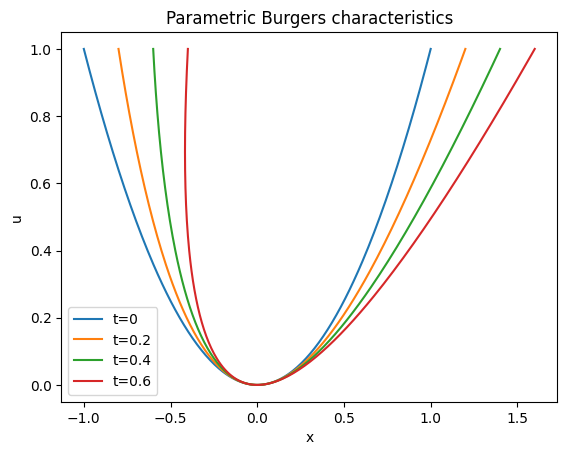

In [6]:
xi = np.linspace(-1.0, 1.0, 240)
fig, ax = plt.subplots()
for tv in [0.0, 0.2, 0.4, 0.6]:
    ax.plot(xi + tv*xi**2, xi**2, label=f"t={tv:g}")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_title("Parametric Burgers characteristics")
ax.legend(); plt.show()

## 3. Variation and exercisesRun the linear initial profile below. Then: (1) compute where the map $\xi\mapsto x$ loses invertibility for a decreasing initial profile; (2) explain why that signals shock formation; (3) compare the implicit result with an explicitly solved quadratic branch where possible.

In [7]:
r2 = pds.pdesolve(eq, u(x,t), (x,t), ics={"initial_profile": x}, method="quasilinear_implicit")
print(r2.method); display(r2.solution)

quasilinear_implicit_characteristics